# Oracle Signal Test

Tests whether the oracle's retrieval advantage over random is **real structured signal** or **pure coverage luck** (having K tries means you're likely to stumble on a good condition by chance).

| Test | Question | Signal if... |
|---|---|---|
| 1 | Win-rate distribution | Wins concentrated in few reps, not uniform |
| 2 | K-coverage curve | Actual curve rises *faster* than geometric null |
| 3 | Oracle rank margin | Gap between best/worst rep is large |
| 4 | Per-image caption consistency | Same rep wins across all captions of an image |
| 5 | Cross-query-type consistency | Same rep wins for cap/des/imp/aes queries of same image |
| 6 | Rep transfer test | A good rep for image A is also good for image B (global quality) |

In [1]:
EXPERIMENT_DIR = (
    "/project/CoSiR/res/CoSiR_Experiment_phase1/impressions/20260602_184636_CoSiR_Experiment"
)
EPOCH   = None   # None = latest
DEVICE  = "cuda"
N_BOOT  = 200    # bootstrap iterations for K-coverage curve
TYPE_NAMES  = ["caption", "description", "impression", "aesthetic"]
TYPE_COLORS = ["#888888", "#2196F3", "#FF9800", "#4CAF50"]

In [2]:
import os, glob
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import spearmanr

print("Imports OK")

Imports OK


In [3]:
cond_dir = os.path.join(EXPERIMENT_DIR, "condition_viz")
ca_dir   = os.path.join(EXPERIMENT_DIR, "condition_analysis")

fixed = torch.load(os.path.join(cond_dir, "fixed_data.pt"), map_location="cpu", weights_only=False)
all_img_emb    = fixed["all_img_emb"]
all_txt_emb    = fixed["all_txt_emb"]
img2txt        = fixed["image_to_text_map"]
txt2img        = fixed["text_to_image_map"]
cpi            = fixed["captions_per_image"]
test_cap_types = fixed["test_caption_types"]
n_img, n_txt   = all_img_emb.shape[0], all_txt_emb.shape[0]
print(f"Test: {n_img} images × {cpi} caps = {n_txt} texts")

epoch_files = sorted(glob.glob(os.path.join(cond_dir, "epoch_*.pt")))
snap = torch.load(
    epoch_files[-1] if EPOCH is None else os.path.join(cond_dir, f"epoch_{EPOCH:04d}.pt"),
    map_location="cpu", weights_only=False
)
epoch         = snap["epoch"]
representatives = snap["representatives"]   # [K, D_cond]
train_types   = snap.get("train_sample_types")
K             = len(representatives)
print(f"Epoch {epoch} | K={K} representatives")

ca_files = sorted(glob.glob(os.path.join(ca_dir, "epoch_*.pt")))
assert ca_files, "No condition_analysis cache found — run with perform_evaluation=True"
ca = torch.load(ca_files[-1], map_location="cpu", weights_only=False)
per_rep_gt_rank = ca["per_rep_gt_rank"]   # [K, N_txt]  lower = better rank
print(f"per_rep_gt_rank: {per_rep_gt_rank.shape}  (K={K}, N_txt={n_txt})")

Test: 706 images × 4 caps = 2824 texts
Epoch 999 | K=30 representatives
per_rep_gt_rank: torch.Size([30, 2824])  (K=30, N_txt=2824)


In [4]:
def r_at_k(ranks, k=1):
    return (ranks < k).float().mean().item() * 100

def oracle_r1(rep_idx):
    """R@1 when best rep is chosen from rep_idx subset."""
    return r_at_k(per_rep_gt_rank[rep_idx].min(0).values)

def random_r1(rep_idx):
    """R@1 when a random single rep is chosen from rep_idx subset per query."""
    chosen = per_rep_gt_rank[rep_idx][torch.randint(len(rep_idx), (n_txt,)), torch.arange(n_txt)]
    return r_at_k(chosen)

# baseline: R@1 using all K reps (true oracle)
r1_oracle_full = oracle_r1(torch.arange(K))
# baseline: R@1 using a single random rep (averaged)
r1_single_avg  = np.mean([random_r1(torch.arange(K)) for _ in range(200)])

print(f"Oracle R@1 (K={K}):      {r1_oracle_full:.2f}%")
print(f"Random single rep R@1:   {r1_single_avg:.2f}%")
print(f"Oracle advantage:        {r1_oracle_full - r1_single_avg:+.2f}pp")

Oracle R@1 (K=30):      80.35%
Random single rep R@1:   60.38%
Oracle advantage:        +19.97pp


---
## Test 1 — Win-rate distribution

If oracle gains are **random coverage**, each representative should win ~1/K of queries (uniform).
If **real signal**, a few representatives are consistently better → wins are concentrated.

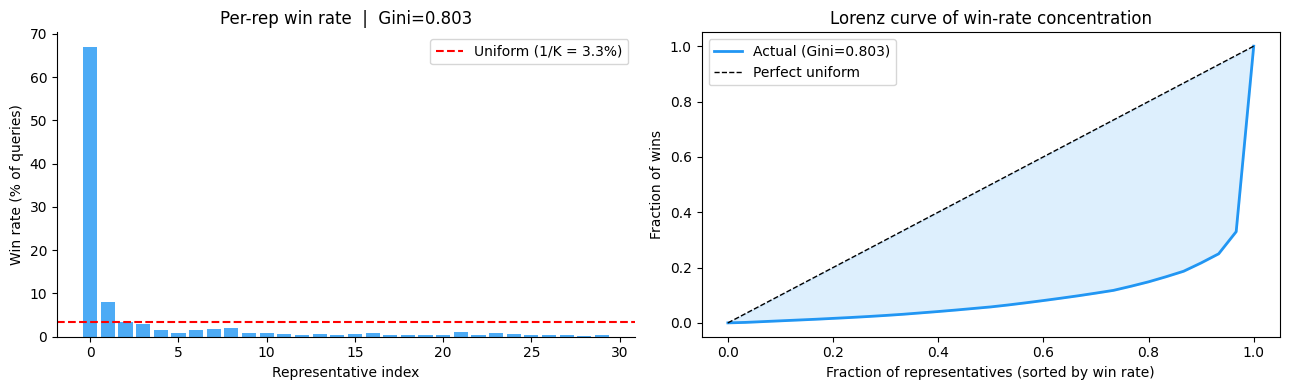

Win-rate Gini coefficient: 0.803  (0=uniform, 1=winner-takes-all)
Top-5 reps account for 83.3% of all wins
Dead reps (zero wins):     0/30
→ Concentrated wins — some reps are consistently better (suggests real signal)


In [5]:
best_rep_per_query = per_rep_gt_rank.argmin(0)   # [N_txt] — which rep wins each query
win_counts = torch.bincount(best_rep_per_query, minlength=K).float()
win_rate   = win_counts / n_txt

# Gini coefficient: 0=uniform, 1=all wins in one rep
wr_sorted = win_rate.sort().values.numpy()
n = len(wr_sorted)
gini = (2 * np.sum((np.arange(1, n+1)) * wr_sorted) / (n * wr_sorted.sum()) - (n+1)/n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(range(K), win_rate.numpy() * 100, color="#2196F3", alpha=0.8)
ax.axhline(100 / K, color="red", lw=1.5, ls="--", label=f"Uniform (1/K = {100/K:.1f}%)")
ax.set_xlabel("Representative index")
ax.set_ylabel("Win rate (% of queries)")
ax.set_title(f"Per-rep win rate  |  Gini={gini:.3f}")
ax.legend()
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Lorenz curve
ax2 = axes[1]
lorenz_x = np.linspace(0, 1, n+1)
lorenz_y = np.concatenate([[0], np.cumsum(wr_sorted) / wr_sorted.sum()])
ax2.plot(lorenz_x, lorenz_y, color="#2196F3", lw=2, label=f"Actual (Gini={gini:.3f})")
ax2.plot([0,1],[0,1], "k--", lw=1, label="Perfect uniform")
ax2.fill_between(lorenz_x, lorenz_y, lorenz_x, alpha=0.15, color="#2196F3")
ax2.set_xlabel("Fraction of representatives (sorted by win rate)")
ax2.set_ylabel("Fraction of wins")
ax2.set_title("Lorenz curve of win-rate concentration")
ax2.legend()

plt.tight_layout(); plt.show()

top5_share = win_rate.sort(descending=True).values[:5].sum().item() * 100
dead_reps  = (win_counts == 0).sum().item()
print(f"Win-rate Gini coefficient: {gini:.3f}  (0=uniform, 1=winner-takes-all)")
print(f"Top-5 reps account for {top5_share:.1f}% of all wins")
print(f"Dead reps (zero wins):     {dead_reps}/{K}")
if gini > 0.3:
    print("→ Concentrated wins — some reps are consistently better (suggests real signal)")
else:
    print("→ Near-uniform wins — all reps win roughly equally (suggests coverage effect)")

---
## Test 1b — Is the top-winning rep just the "default average" condition?

If the most-winning representative is simply the one closest to the mean condition,
its wins reflect "adequate for everything" rather than "specifically good for some images."

Three checks:
- **Proximity to mean**: is the top winner closest to the mean condition in condition space?
- **Ablation**: how much does oracle R@1 drop when the top winner is removed? Large drop → it was a generic default, not a specific signal.
- **Win selectivity**: does the top winner win uniformly across all queries (=default) or selectively for specific images (=real preference)?

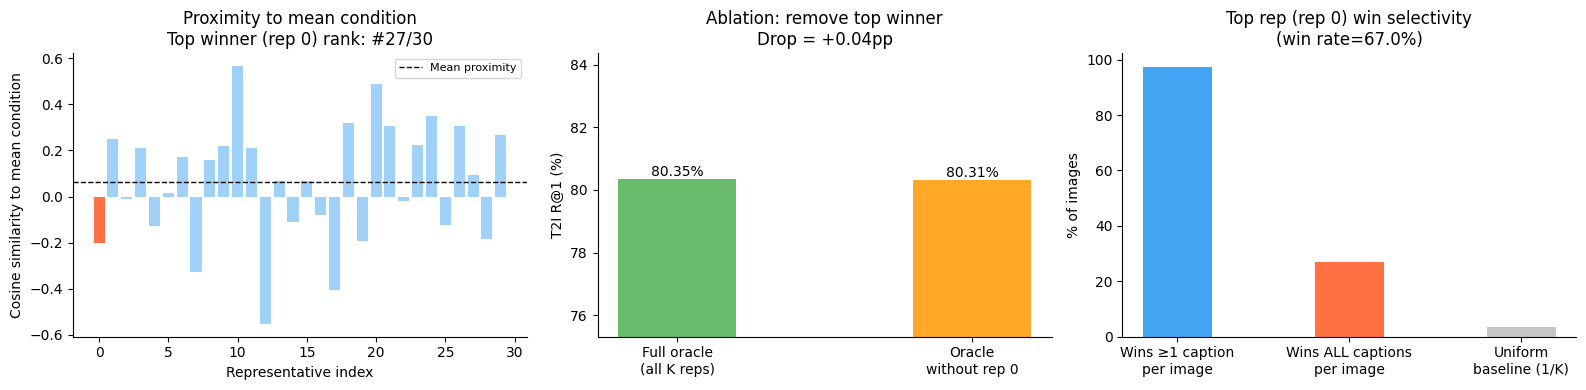

Top-winning rep: #0  (win rate=67.0% vs uniform=3.3%)
  Proximity to mean condition: cos=-0.200  rank=#27/30
  (rank #1 = closest to mean → 'default avg' hypothesis; rank #30 = furthest → genuinely specific)

Ablation (remove rep 0):
  Oracle with all K:      80.35%
  Oracle without rep 0:  80.31%  (drop=+0.04pp)
  → Negligible drop: rep 0 is substitutable → likely acting as 'generic default'

Win selectivity of rep 0:
  Wins ≥1 caption for 97.5% of images  (uniform baseline=3.3%)
  Wins ALL captions for 26.9% of images
  → Wins broadly across most images → consistent with 'default avg' role


In [6]:
top_rep   = int(win_rate.argmax())
top_wr    = win_rate[top_rep].item() * 100
other_idx = torch.tensor([k for k in range(K) if k != top_rep])

# ── Check 1: proximity to mean condition ──────────────────────────────────────
reps_n    = F.normalize(representatives, dim=-1)            # [K, D]
mean_cond = representatives.mean(0, keepdim=True)           # [1, D]
mean_cond_n = F.normalize(mean_cond, dim=-1)
cos_to_mean = (reps_n @ mean_cond_n.T).squeeze()            # [K]
top_rep_cos_to_mean = cos_to_mean[top_rep].item()
rank_by_proximity  = int((cos_to_mean > top_rep_cos_to_mean).sum().item()) + 1

# ── Check 2: oracle ablation — remove top winner ──────────────────────────────
r1_without_top = oracle_r1(other_idx)
ablation_drop  = r1_oracle_full - r1_without_top

# ── Check 3: win selectivity — does top rep win uniformly or selectively? ─────
# Compare: (a) fraction of images where top rep wins ALL their captions
#          (b) fraction of images where top rep wins ANY caption
img_top_win_any = torch.zeros(n_img, dtype=torch.bool)
img_top_win_all = torch.zeros(n_img, dtype=torch.bool)
for img_i in range(n_img):
    img_txt_list = img2txt[img_i].tolist() if isinstance(img2txt[img_i], torch.Tensor) else list(img2txt[img_i])
    wins = [best_rep_per_query[q].item() == top_rep for q in img_txt_list]
    img_top_win_any[img_i] = any(wins)
    img_top_win_all[img_i] = all(wins)

pct_any = img_top_win_any.float().mean().item() * 100
pct_all = img_top_win_all.float().mean().item() * 100

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# proximity to mean
ax = axes[0]
colors_prox = ["#FF5722" if k == top_rep else "#90CAF9" for k in range(K)]
ax.bar(range(K), cos_to_mean.numpy(), color=colors_prox, alpha=0.85)
ax.axhline(cos_to_mean.mean().item(), color="k", lw=1, ls="--", label="Mean proximity")
ax.set_xlabel("Representative index")
ax.set_ylabel("Cosine similarity to mean condition")
ax.set_title(f"Proximity to mean condition\nTop winner (rep {top_rep}) rank: #{rank_by_proximity}/{K}")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# ablation
ax2 = axes[1]
bars = ax2.bar(["Full oracle\n(all K reps)", f"Oracle\nwithout rep {top_rep}"],
               [r1_oracle_full, r1_without_top],
               color=["#4CAF50", "#FF9800"], alpha=0.85, width=0.4)
for bar, v in zip(bars, [r1_oracle_full, r1_without_top]):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.1, f"{v:.2f}%",
             ha="center", fontsize=10)
ax2.set_ylabel("T2I R@1 (%)")
ax2.set_title(f"Ablation: remove top winner\nDrop = {ablation_drop:+.2f}pp")
ax2.set_ylim(bottom=max(0, r1_without_top - 5))
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# selectivity
ax3 = axes[2]
ax3.bar(["Wins ≥1 caption\nper image", "Wins ALL captions\nper image", "Uniform\nbaseline (1/K)"],
        [pct_any, pct_all, 100/K],
        color=["#2196F3", "#FF5722", "#bdbdbd"], alpha=0.85, width=0.4)
ax3.set_ylabel("% of images")
ax3.set_title(f"Top rep (rep {top_rep}) win selectivity\n(win rate={top_wr:.1f}%)")
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

print(f"Top-winning rep: #{top_rep}  (win rate={top_wr:.1f}% vs uniform={100/K:.1f}%)")
print(f"  Proximity to mean condition: cos={top_rep_cos_to_mean:.3f}  rank=#{rank_by_proximity}/{K}")
print(f"  (rank #1 = closest to mean → 'default avg' hypothesis; rank #{K} = furthest → genuinely specific)")
print(f"\nAblation (remove rep {top_rep}):")
print(f"  Oracle with all K:      {r1_oracle_full:.2f}%")
print(f"  Oracle without rep {top_rep}:  {r1_without_top:.2f}%  (drop={ablation_drop:+.2f}pp)")
if ablation_drop < 0.5:
    print(f"  → Negligible drop: rep {top_rep} is substitutable → likely acting as 'generic default'")
elif ablation_drop < 2.0:
    print(f"  → Small drop: rep {top_rep} helps but others can partially compensate")
else:
    print(f"  → Large drop: rep {top_rep} carries unique signal — genuinely important")
print(f"\nWin selectivity of rep {top_rep}:")
print(f"  Wins ≥1 caption for {pct_any:.1f}% of images  (uniform baseline={100/K:.1f}%)")
print(f"  Wins ALL captions for {pct_all:.1f}% of images")
if pct_any > 60:
    print(f"  → Wins broadly across most images → consistent with 'default avg' role")
else:
    print(f"  → Selective wins → consistent with genuinely image-specific preference")

Tie analysis (how many reps share the best rank per query):
  Mean # reps tied at best rank: 19.26 / 30
  Queries with unique winner (no tie): 12.3%
  Queries where ALL reps tie:          36.3%


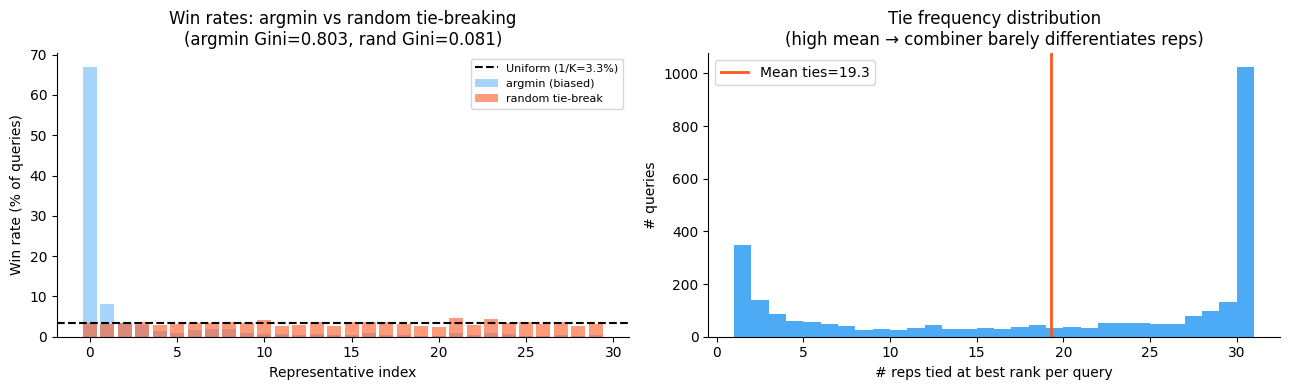


With random tie-breaking:
  Gini coefficient: 0.081  (argmin Gini was 0.803)
  → Near-uniform after correcting for ties → win concentration was argmin artifact
  → The combiner barely differentiates between reps; many are interchangeable


In [7]:
# ── T1c: How many reps tie for best rank per query? ───────────────────────────
best_rank_per_query = per_rep_gt_rank.min(0).values   # [N_txt]
n_tied = (per_rep_gt_rank == best_rank_per_query.unsqueeze(0)).sum(0).float()  # [N_txt]

print(f"Tie analysis (how many reps share the best rank per query):")
print(f"  Mean # reps tied at best rank: {n_tied.mean():.2f} / {K}")
print(f"  Queries with unique winner (no tie): {(n_tied == 1).float().mean()*100:.1f}%")
print(f"  Queries where ALL reps tie:          {(n_tied == K).float().mean()*100:.1f}%")

# ── Win rate with random tie-breaking ─────────────────────────────────────────
torch.manual_seed(42)
# For each query, randomly pick one rep among those tied at the best rank
tie_mask = (per_rep_gt_rank == best_rank_per_query.unsqueeze(0))  # [K, N_txt]
# Sample random winner among tied reps
rand_noise = torch.rand(K, n_txt)
rand_noise[~tie_mask] = -1.0   # non-tied reps can't win
rand_winner = rand_noise.argmax(0)   # [N_txt]

win_counts_rand = torch.bincount(rand_winner, minlength=K).float()
win_rate_rand   = win_counts_rand / n_txt
gini_rand = None
wr_sorted_r = win_rate_rand.sort().values.numpy()
n = len(wr_sorted_r)
if wr_sorted_r.sum() > 0:
    gini_rand = (2 * np.sum((np.arange(1,n+1)) * wr_sorted_r) / (n * wr_sorted_r.sum()) - (n+1)/n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(range(K), win_rate.numpy()*100, color="#90CAF9", alpha=0.8, label="argmin (biased)")
ax.bar(range(K), win_rate_rand.numpy()*100, color="#FF5722", alpha=0.6, label="random tie-break")
ax.axhline(100/K, color="k", lw=1.5, ls="--", label=f"Uniform (1/K={100/K:.1f}%)")
ax.set_xlabel("Representative index")
ax.set_ylabel("Win rate (% of queries)")
ax.set_title(f"Win rates: argmin vs random tie-breaking\n(argmin Gini={gini:.3f}, rand Gini={gini_rand:.3f})")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax2 = axes[1]
ax2.hist(n_tied.numpy(), bins=range(1, K+2), color="#2196F3", alpha=0.8)
ax2.axvline(n_tied.mean().item(), color="#FF5722", lw=2,
            label=f"Mean ties={n_tied.mean():.1f}")
ax2.set_xlabel("# reps tied at best rank per query")
ax2.set_ylabel("# queries")
ax2.set_title("Tie frequency distribution\n(high mean → combiner barely differentiates reps)")
ax2.legend()
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

print(f"\nWith random tie-breaking:")
print(f"  Gini coefficient: {gini_rand:.3f}  (argmin Gini was {gini:.3f})")
if gini_rand < 0.15:
    print(f"  → Near-uniform after correcting for ties → win concentration was argmin artifact")
    print(f"  → The combiner barely differentiates between reps; many are interchangeable")
else:
    print(f"  → Concentration remains after correcting for ties → real signal exists")

---
## Test 2 — K-coverage curve vs geometric null

**Null model**: if oracle gains come from coverage (K random tries), oracle R@1 should follow:
`R@1(K) = R@1(1) + [R@1(K_max) - R@1(1)] * [1 - (1-p)^K] / [1-(1-p)^K_max]`
i.e., a geometric saturation curve — early tries give most of the gain.

If the actual curve rises **faster** than the null (convex rather than concave shape), 
some representatives are better than random — structured signal exists.

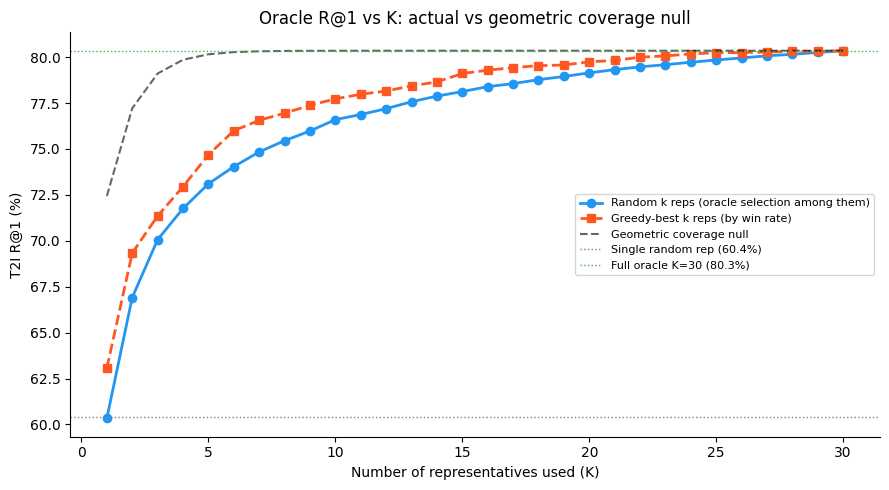

Area above geometric null (signal ratio): -1.029
  > 0: actual curve beats null → real structure beyond coverage
  ≈ 0: actual curve matches null → pure coverage effect
  < 0: actual curve below null → reps negatively structured (anti-signal)


In [8]:
torch.manual_seed(0); np.random.seed(0)
k_vals = list(range(1, K+1))

# Actual oracle curve: randomly sample k reps, take oracle R@1
r1_random_oracle = []
for k in k_vals:
    trials = []
    for _ in range(N_BOOT):
        idx = torch.randperm(K)[:k]
        trials.append(oracle_r1(idx))
    r1_random_oracle.append(np.mean(trials))

# Greedy-best oracle curve: pick k reps with highest win rates
sorted_by_wins = win_rate.argsort(descending=True)
r1_greedy = [oracle_r1(sorted_by_wins[:k]) for k in k_vals]

# Geometric null model: calibrated to match k=1 and k=K
p_null = r1_single_avg / 100
geo_null = [r1_single_avg + (r1_oracle_full - r1_single_avg) *
            (1 - (1-p_null)**k) / (1 - (1-p_null)**K)
            for k in k_vals]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_vals, r1_random_oracle, "o-", color="#2196F3", lw=2,
        label="Random k reps (oracle selection among them)")
ax.plot(k_vals, r1_greedy, "s--", color="#FF5722", lw=2,
        label="Greedy-best k reps (by win rate)")
ax.plot(k_vals, geo_null, "k--", lw=1.5, alpha=0.6,
        label="Geometric coverage null")
ax.axhline(r1_single_avg, color="gray", lw=1, ls=":", label=f"Single random rep ({r1_single_avg:.1f}%)")
ax.axhline(r1_oracle_full, color="#4CAF50", lw=1, ls=":", label=f"Full oracle K={K} ({r1_oracle_full:.1f}%)")
ax.set_xlabel("Number of representatives used (K)")
ax.set_ylabel("T2I R@1 (%)")
ax.set_title("Oracle R@1 vs K: actual vs geometric coverage null")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

# Area above null (actual - null) normalized by total possible area
actual_area = np.trapezoid(r1_random_oracle, k_vals)
null_area   = np.trapezoid(geo_null, k_vals)
max_area    = r1_oracle_full * K
signal_ratio = (actual_area - null_area) / (max_area - null_area + 1e-8)
print(f"Area above geometric null (signal ratio): {signal_ratio:.3f}")
print(f"  > 0: actual curve beats null → real structure beyond coverage")
print(f"  ≈ 0: actual curve matches null → pure coverage effect")
print(f"  < 0: actual curve below null → reps negatively structured (anti-signal)")

---
## Test 3 — Oracle rank margin

For each query, how large is the gap between the best and worst representative rank?
Large margin → some reps are much better than others (real preference).
Small margin → all reps perform roughly the same (noise).

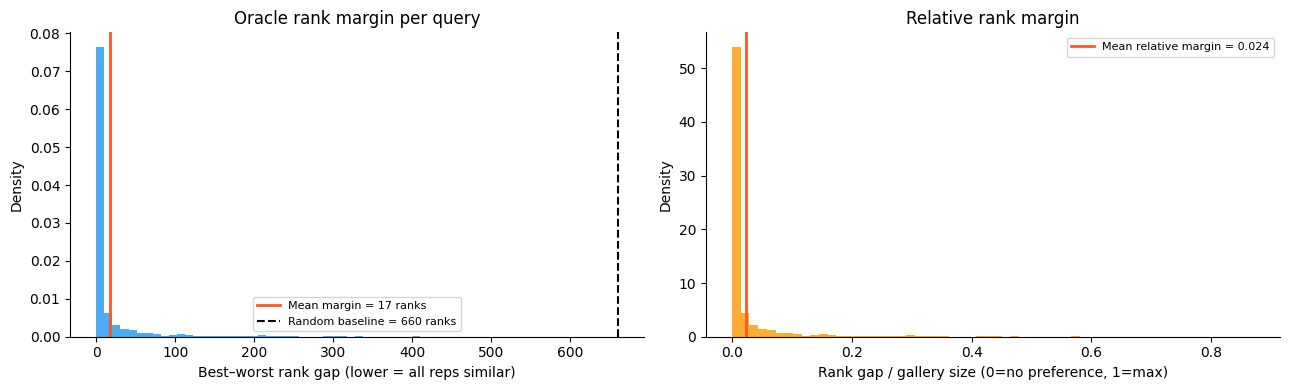

Mean rank margin:         17.0 / 706 (0.024 relative)
Expected random margin:   660 (0.935 relative)
Queries with <5% margin:  89.2%  (all reps nearly equivalent)
Queries with >30% margin: 1.8%  (strong rep preference)


In [9]:
best_rank  = per_rep_gt_rank.min(0).values.float()   # [N_txt]
worst_rank = per_rep_gt_rank.max(0).values.float()   # [N_txt]
margin     = worst_rank - best_rank                  # [N_txt] — rank gap

# Normalise by gallery size (n_img) to get relative margin
rel_margin = margin / n_img

# Expected margin if all reps give the SAME rank: 0
# Expected margin if reps are uniformly random: ~(K-1)/(K+1) * n_img
expected_random_margin = (K - 1) / (K + 1) * n_img

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(margin.numpy(), bins=60, color="#2196F3", alpha=0.8, density=True)
ax.axvline(margin.mean().item(), color="#FF5722", lw=2,
           label=f"Mean margin = {margin.mean():.0f} ranks")
ax.axvline(expected_random_margin, color="k", lw=1.5, ls="--",
           label=f"Random baseline = {expected_random_margin:.0f} ranks")
ax.set_xlabel("Best–worst rank gap (lower = all reps similar)")
ax.set_ylabel("Density")
ax.set_title("Oracle rank margin per query")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax2 = axes[1]
ax2.hist(rel_margin.numpy(), bins=60, color="#FF9800", alpha=0.8, density=True)
ax2.axvline(rel_margin.mean().item(), color="#FF5722", lw=2,
            label=f"Mean relative margin = {rel_margin.mean():.3f}")
ax2.set_xlabel("Rank gap / gallery size (0=no preference, 1=max)")
ax2.set_ylabel("Density")
ax2.set_title("Relative rank margin")
ax2.legend(fontsize=8)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

pct_small_margin = (rel_margin < 0.05).float().mean().item() * 100
pct_large_margin = (rel_margin > 0.30).float().mean().item() * 100
print(f"Mean rank margin:         {margin.mean():.1f} / {n_img} ({rel_margin.mean():.3f} relative)")
print(f"Expected random margin:   {expected_random_margin:.0f} ({expected_random_margin/n_img:.3f} relative)")
print(f"Queries with <5% margin:  {pct_small_margin:.1f}%  (all reps nearly equivalent)")
print(f"Queries with >30% margin: {pct_large_margin:.1f}%  (strong rep preference)")

---
## Test 4 — Per-image caption consistency

Each image has `cpi` captions. If the oracle selects the same representative for all captions
of the same image, that's an **image-level** pattern — the predictor could learn it.
If the winner changes per caption, the pattern is **query-specific** and unlearnable from image only.

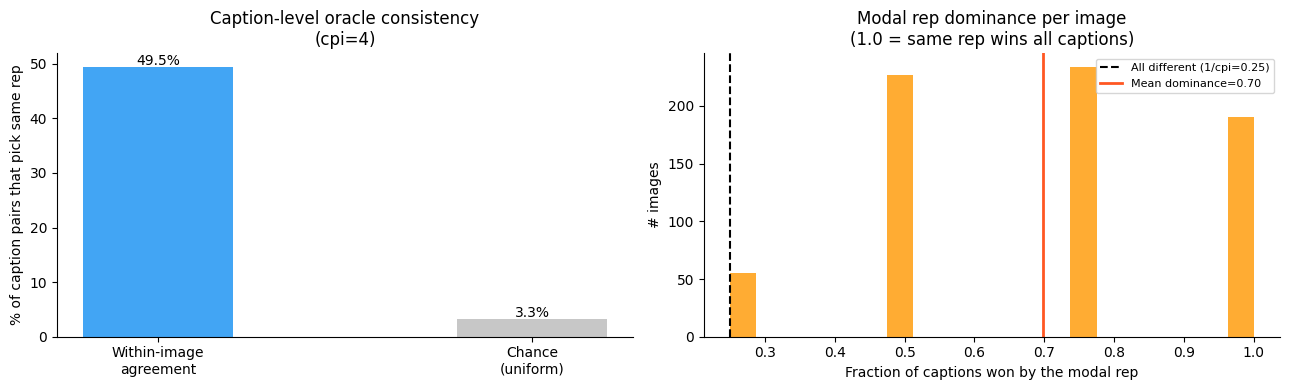

Within-image caption agreement: 49.5%
Chance baseline (uniform):       3.3%
Lift over chance:               +46.1pp
Mean modal rep dominance:        0.698  (1.0 = perfect consistency)
Images where all captions agree: 26.9%


In [10]:
# For each image, which rep wins each of its cpi captions?
oracle_rep_per_query = per_rep_gt_rank.argmin(0)   # [N_txt]

# Agreement: fraction of caption pairs for the same image that pick the same rep
within_image_agreements = []
modal_rep_per_image = []  # majority-vote rep for each image
for img_i in range(n_img):
    txt_ids = img2txt[img_i]   # caption indices for this image
    reps_for_img = oracle_rep_per_query[txt_ids].numpy()
    modal_rep = int(np.bincount(reps_for_img).argmax())
    modal_rep_per_image.append(modal_rep)
    if len(reps_for_img) > 1:
        pairs = [(reps_for_img[i] == reps_for_img[j])
                 for i in range(len(reps_for_img)) for j in range(i+1, len(reps_for_img))]
        within_image_agreements.extend(pairs)

within_agree = np.mean(within_image_agreements) * 100
chance_agree = 100 / K  # if each query independently picks uniform random rep

# Distribution of "dominance": fraction of captions won by the modal rep
dominance = []
for img_i in range(n_img):
    txt_ids = img2txt[img_i]
    reps_for_img = oracle_rep_per_query[txt_ids].numpy()
    counts = np.bincount(reps_for_img, minlength=K)
    dominance.append(counts.max() / len(reps_for_img))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(["Within-image\nagreement", "Chance\n(uniform)"],
       [within_agree, chance_agree],
       color=["#2196F3", "#bdbdbd"], alpha=0.85, width=0.4)
ax.set_ylabel("% of caption pairs that pick same rep")
ax.set_title(f"Caption-level oracle consistency\n(cpi={cpi})")
for i, v in enumerate([within_agree, chance_agree]):
    ax.text(i, v+0.3, f"{v:.1f}%", ha="center", fontsize=10)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax2 = axes[1]
ax2.hist(dominance, bins=20, color="#FF9800", alpha=0.8)
ax2.axvline(1/cpi, color="k", lw=1.5, ls="--",
            label=f"All different (1/cpi={1/cpi:.2f})")
ax2.axvline(np.mean(dominance), color="#FF5722", lw=2,
            label=f"Mean dominance={np.mean(dominance):.2f}")
ax2.set_xlabel("Fraction of captions won by the modal rep")
ax2.set_ylabel("# images")
ax2.set_title("Modal rep dominance per image\n(1.0 = same rep wins all captions)")
ax2.legend(fontsize=8)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

print(f"Within-image caption agreement: {within_agree:.1f}%")
print(f"Chance baseline (uniform):       {chance_agree:.1f}%")
print(f"Lift over chance:               {within_agree - chance_agree:+.1f}pp")
print(f"Mean modal rep dominance:        {np.mean(dominance):.3f}  (1.0 = perfect consistency)")
pct_full = np.mean(np.array(dominance) == 1.0) * 100
print(f"Images where all captions agree: {pct_full:.1f}%")

---
## Test 5 — Cross-query-type consistency

For each image, what rep wins for caption queries vs description queries vs impression vs aesthetic?
High agreement across query types → image-level pattern, predictor could learn it.
Low agreement → the best condition is query-type-dependent (predictor ceiling is lower).

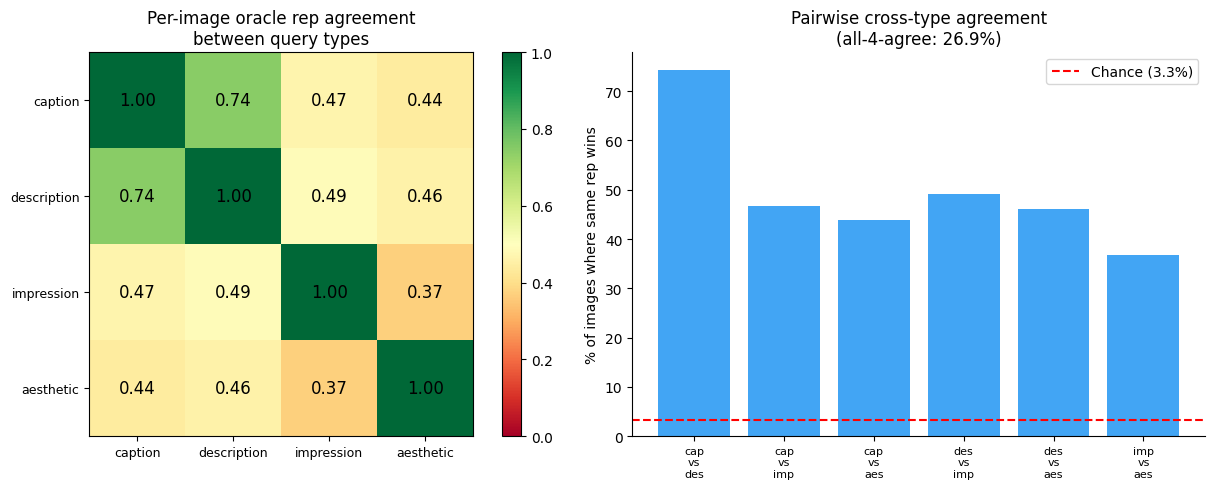

Cross-type agreement matrix:
  Pairwise means: ['74.2%', '46.7%', '43.8%', '49.2%', '46.0%', '36.8%']
  All-4-types agree: 26.9%
  Chance baseline:   3.3%
  Lift over chance:  +23.6pp


In [11]:
type_idx = [(test_cap_types == t).nonzero(as_tuple=True)[0] for t in range(4)]
oracle_rep_per_query = per_rep_gt_rank.argmin(0)   # [N_txt]

# For each image × query-type, find the oracle rep
oracle_rep_by_type = torch.full((4, n_img), -1, dtype=torch.long)
for t in range(4):
    tidx_set = set(type_idx[t].tolist())   # Python ints — safe for set membership
    for img_i in range(n_img):
        img_txt = img2txt[img_i]
        # ensure Python ints regardless of img2txt storage type
        img_txt_list = img_txt.tolist() if isinstance(img_txt, torch.Tensor) else list(img_txt)
        type_txt = [q for q in img_txt_list if q in tidx_set]
        if type_txt:
            mean_rank = per_rep_gt_rank[:, type_txt].float().mean(1)  # [K]
            oracle_rep_by_type[t, img_i] = mean_rank.argmin()

# Pairwise agreement between query types (per-image: same rep wins?)
from itertools import combinations
type_pairs = list(combinations(range(4), 2))
agree_mat = np.zeros((4, 4))
for t1, t2 in type_pairs:
    valid = (oracle_rep_by_type[t1] >= 0) & (oracle_rep_by_type[t2] >= 0)
    if valid.any():
        agree = (oracle_rep_by_type[t1, valid] == oracle_rep_by_type[t2, valid]).float().mean().item()
    else:
        agree = float("nan")
    agree_mat[t1, t2] = agree_mat[t2, t1] = agree
np.fill_diagonal(agree_mat, 1.0)

# Overall: all 4 types agree on the same rep
valid_all = (oracle_rep_by_type >= 0).all(0)
if valid_all.any():
    all_agree = (oracle_rep_by_type[:, valid_all] == oracle_rep_by_type[0:1, valid_all]).all(0).float().mean().item()
else:
    all_agree = float("nan")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
im = ax.imshow(agree_mat, cmap="RdYlGn", vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{agree_mat[i,j]:.2f}" if not np.isnan(agree_mat[i,j]) else "n/a",
                ha="center", va="center", fontsize=12)
ax.set_xticks(range(4)); ax.set_xticklabels(TYPE_NAMES, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(TYPE_NAMES, fontsize=9)
ax.set_title("Per-image oracle rep agreement\nbetween query types")
plt.colorbar(im, ax=ax)

ax2 = axes[1]
pair_agrees = [agree_mat[t1, t2] * 100 for t1, t2 in type_pairs]
pair_labels = [f"{TYPE_NAMES[t1][:3]}\nvs\n{TYPE_NAMES[t2][:3]}" for t1, t2 in type_pairs]
bars = ax2.bar(range(len(type_pairs)), pair_agrees, color="#2196F3", alpha=0.85)
ax2.axhline(chance_agree, color="red", lw=1.5, ls="--", label=f"Chance ({chance_agree:.1f}%)")
ax2.set_xticks(range(len(type_pairs)))
ax2.set_xticklabels(pair_labels, fontsize=8)
ax2.set_ylabel("% of images where same rep wins")
ax2.set_title(f"Pairwise cross-type agreement\n(all-4-agree: {all_agree*100:.1f}%)")
ax2.legend()
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

print(f"Cross-type agreement matrix:")
print(f"  Pairwise means: {[f'{agree_mat[t1,t2]*100:.1f}%' for t1,t2 in type_pairs]}")
print(f"  All-4-types agree: {all_agree*100:.1f}%")
print(f"  Chance baseline:   {chance_agree:.1f}%")
print(f"  Lift over chance:  {all_agree*100 - chance_agree:+.1f}pp")

---
## Test 6 — Representative transfer test

If there are globally "good" and "bad" representatives, a rep that wins for image A should also
win more often for image B (Spearman ρ between per-rep win rates across different image subsets).

If ρ is high → rep quality is global (some reps are just better in general → real structure).
If ρ ≈ 0 → each image needs a different rep (image-specific, not globally predictable).

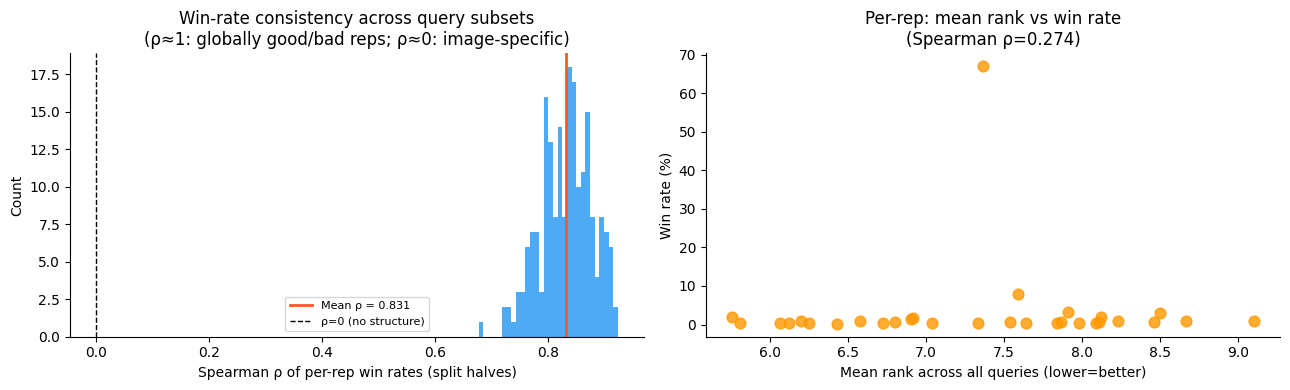

Split-half win-rate Spearman ρ: 0.831 ± 0.046
  ρ > 0.5: reps have consistent global quality → real structure
  ρ ≈ 0.0: win rate is query-set specific → mostly noise / coverage
Mean-rank vs win-rate ρ: 0.274  (expect negative: lower rank → more wins)


In [12]:
torch.manual_seed(0); np.random.seed(0)

# Split queries into 2 halves randomly, compute per-rep win rate in each half
# Repeat N_BOOT times and measure Spearman ρ between win rates
split_rhos = []
for _ in range(N_BOOT):
    perm = torch.randperm(n_txt)
    half = n_txt // 2
    idx_a, idx_b = perm[:half], perm[half:]
    wr_a = torch.bincount(per_rep_gt_rank[:, idx_a].argmin(0), minlength=K).float() / half
    wr_b = torch.bincount(per_rep_gt_rank[:, idx_b].argmin(0), minlength=K).float() / (n_txt - half)
    rho, _ = spearmanr(wr_a.numpy(), wr_b.numpy())
    split_rhos.append(rho)

# Also compute per-rep mean rank (lower = better rep globally)
mean_rank_per_rep = per_rep_gt_rank.float().mean(1)   # [K]
# Does a rep's global mean rank predict its win rate? (should be anti-correlated)
rank_vs_wins_rho, _ = spearmanr(mean_rank_per_rep.numpy(), win_rate.numpy())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(split_rhos, bins=30, color="#2196F3", alpha=0.8)
ax.axvline(np.mean(split_rhos), color="#FF5722", lw=2,
           label=f"Mean ρ = {np.mean(split_rhos):.3f}")
ax.axvline(0, color="k", lw=1, ls="--", label="ρ=0 (no structure)")
ax.set_xlabel("Spearman ρ of per-rep win rates (split halves)")
ax.set_ylabel("Count")
ax.set_title("Win-rate consistency across query subsets\n(ρ≈1: globally good/bad reps; ρ≈0: image-specific)")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax2 = axes[1]
ax2.scatter(mean_rank_per_rep.numpy(), win_rate.numpy() * 100,
            color="#FF9800", alpha=0.8, s=60)
ax2.set_xlabel("Mean rank across all queries (lower=better)")
ax2.set_ylabel("Win rate (%)")
ax2.set_title(f"Per-rep: mean rank vs win rate\n(Spearman ρ={rank_vs_wins_rho:.3f})")
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

print(f"Split-half win-rate Spearman ρ: {np.mean(split_rhos):.3f} ± {np.std(split_rhos):.3f}")
print(f"  ρ > 0.5: reps have consistent global quality → real structure")
print(f"  ρ ≈ 0.0: win rate is query-set specific → mostly noise / coverage")
print(f"Mean-rank vs win-rate ρ: {rank_vs_wins_rho:.3f}  (expect negative: lower rank → more wins)")

---
## Summary

In [13]:
print("━" * 60)
print("  ORACLE SIGNAL SUMMARY")
print("━" * 60)

signals, noises = [], []

# T1: Gini
t1 = "real" if gini > 0.25 else "noise"
print(f"\nT1 Win-rate concentration:  Gini={gini:.3f}")
print(f"   {'✓ Concentrated wins → real signal' if t1=='real' else '✗ Uniform wins → coverage effect'}")
(signals if t1=="real" else noises).append("T1")

# T2: K-curve
t2 = "real" if signal_ratio > 0.05 else "noise"
print(f"\nT2 K-coverage curve:        signal_ratio={signal_ratio:.3f}")
print(f"   {'✓ Above null → structure beyond coverage' if t2=='real' else '✗ Matches null → pure coverage'}")
(signals if t2=="real" else noises).append("T2")

# T3: Margin
t3 = "real" if rel_margin.mean().item() > 0.15 else "noise"
print(f"\nT3 Oracle rank margin:      mean_rel={rel_margin.mean():.3f}")
print(f"   {'✓ Large margin → strong per-query preference' if t3=='real' else '✗ Small margin → reps nearly equivalent'}")
(signals if t3=="real" else noises).append("T3")

# T4: Caption consistency
lift_t4 = within_agree - chance_agree
t4 = "real" if lift_t4 > 5 else "noise"
print(f"\nT4 Caption consistency:     lift={lift_t4:+.1f}pp over chance")
print(f"   {'✓ Same rep wins across captions → image-level pattern' if t4=='real' else '✗ Captions pick different reps → query-specific'}")
(signals if t4=="real" else noises).append("T4")

# T5: Cross-type
lift_t5 = all_agree * 100 - chance_agree
t5 = "real" if lift_t5 > 5 else "noise"
print(f"\nT5 Cross-type consistency:  lift={lift_t5:+.1f}pp over chance")
print(f"   {'✓ Same rep wins across query types → image-level' if t5=='real' else '✗ Varies by query type → predictor ceiling limited'}")
(signals if t5=="real" else noises).append("T5")

# T6: Transfer
mean_rho = np.mean(split_rhos)
t6 = "real" if mean_rho > 0.4 else "noise"
print(f"\nT6 Rep transfer (split-half ρ): {mean_rho:.3f}")
print(f"   {'✓ Consistent quality across query subsets → global structure' if t6=='real' else '✗ Inconsistent quality → image-specific / noise'}")
(signals if t6=="real" else noises).append("T6")

print(f"\n━" * 60)
print(f"Signal tests: {len(signals)}/6  ({', '.join(signals) or 'none'})")
print(f"Noise  tests: {len(noises)}/6  ({', '.join(noises) or 'none'})")
if len(signals) >= 4:
    print("\n→ VERDICT: Oracle signal is REAL — structured patterns exist.")
    print("  The 10pp oracle gap is worth pursuing.")
elif len(signals) >= 2:
    print("\n→ VERDICT: MIXED — some structure, some coverage.")
    print("  Oracle gap is partially real but partly from K tries.")
else:
    print("\n→ VERDICT: NOISE — oracle gains are mostly from having K tries.")
    print("  10pp gap is not a real learning target; focus on other improvements.")
print("━" * 60)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ORACLE SIGNAL SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

T1 Win-rate concentration:  Gini=0.803
   ✓ Concentrated wins → real signal

T2 K-coverage curve:        signal_ratio=-1.029
   ✗ Matches null → pure coverage

T3 Oracle rank margin:      mean_rel=0.024
   ✗ Small margin → reps nearly equivalent

T4 Caption consistency:     lift=+46.1pp over chance
   ✓ Same rep wins across captions → image-level pattern

T5 Cross-type consistency:  lift=+23.6pp over chance
   ✓ Same rep wins across query types → image-level

T6 Rep transfer (split-half ρ): 0.831
   ✓ Consistent quality across query subsets → global structure

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
Signal tests: 4/6  (T1, T4, T5, T6)
Noise  tests: 2/6  (T2, T3)

→ VERDICT: Oracle signal is REAL — structured patterns exist.
  The 10pp oracle gap is worth pursuing